<a href="https://colab.research.google.com/github/yeshaa23/ZARA-AppsReview-SentimentAnalysis/blob/main/Tugas_1B_TF_IDF_Sentence_Manchester.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas 1B - TF-IDF Sentence Manchester

## Import Dependencies

In [1]:
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')

from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import pandas as pd
import math
import re

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


## Define Document

In [3]:
sentence = """Manchester City makes history by winning Club World Cup. Manchester City capped off its incredible year with yet another trophy, dismantling Fluminense 4-0 to win the Club World Cup on Friday.
Having already won the Premier League, Champions League, FA Cup and Super Cup, Pep Guardiola’s side now boasts five trophies this calendar year, becoming the first English club to ever hold all those titles simultaneously.
The final piece of the jigsaw came on a highly charged night in Saudi Arabia as Manchester City outclassed its Brazilian opponents.
“We’ve shown over the past 12 months we are the best team in the world. Our results prove that and the consistency we have managed has been amazing,” club captain Kyle Walker said after the game, per Sky Sports.
“To win these five trophies – for me, the five biggest prizes available to us – is incredible. I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players. I couldn’t ask for better teammates.”
It took just 40 seconds for Manchester City to take the lead.
Brazilian left-back Marcelo miscued a pass in the opening exchanges which let Nathan Aké free to shoot from distance. The defender’s effort cannoned back off the post but forward Julián Álvarez was in the right place to turn the rebound into the net with his chest.
City continued to look dangerous and doubled its lead before the break after Phil Foden’s attempted cross was deflected into his own net by Fluminense defender Nino.
Foden then got on the scoresheet himself in the 72nd minute after a prodding home from close range.
The rout was completed in the 88th minute when Álvarez capped off a brilliant performance with a clinical finish into the far corner.
City’s defence was largely untested for during the game, underlining the team’s dominance during this unforgettable year.
“As a manager it is what I am most proud of; that we are always there. No matter how much we win, no matter what trophies we lift, we are there again to fight for the next one,” City boss Guardiola said after the match, according to Sky Sports.
“To win the Treble was truly special, but to win two more trophies and now hold these five major titles shows the unique mentality of this team, of the Club and its fans.
“It is something no other English team has ever achieved, and we will always remember this incredible time we spent together.”
The game ended in some unsavoury scenes as a scuffle broke out between players on the pitch after the final whistle, but the game will be remembered as yet another successful night for City.
The champion heads back to England where it faces a tough title defence in the Premier League.
It currently sits fourth in the table and will face Everton in its next fixture on Wednesday.
"""

## Text Preprocessing

In [4]:
stopword_en = {
    'the', 'and', 'to', 'of', 'in', 'a', 'is', 'it', 'for', 'on', 'that',
    'with', 'as', 'its', 'was', 'we', 'are', 'this', 'they', 'will', 'be',
    'by', 'an', 'at', 'from', 'their', 'after', 'into', 'what', 'but',
    'have', 'has', 'had', 'were', 'his', 'her', 'he', 'she', 'them', 'our',
    'us', 'no', 'more', 'all', 'yet', 'now', 'out', 'off', 'just', 'very',
    'again', 'there', 'over', 'during', 'other', 'this', 'these', 'those',
    'can', 'could', 'would', 'should', 'or', 'if', 'then', 'up'
}

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    words = [w for w in words if w not in stopword_en and len(w) > 2]
    return ' '.join(words)

## Sentence Tokenization

In [5]:
sent_token = sent_tokenize(sentence)
print(sent_token)

['Manchester City makes history by winning Club World Cup.', 'Manchester City capped off its incredible year with yet another trophy, dismantling Fluminense 4-0 to win the Club World Cup on Friday.', 'Having already won the Premier League, Champions League, FA Cup and Super Cup, Pep Guardiola’s side now boasts five trophies this calendar year, becoming the first English club to ever hold all those titles simultaneously.', 'The final piece of the jigsaw came on a highly charged night in Saudi Arabia as Manchester City outclassed its Brazilian opponents.', '“We’ve shown over the past 12 months we are the best team in the world.', 'Our results prove that and the consistency we have managed has been amazing,” club captain Kyle Walker said after the game, per Sky Sports.', '“To win these five trophies – for me, the five biggest prizes available to us – is incredible.', 'I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players.', 'I coul

In [6]:
cleaned_sentences = [clean_text(sent) for sent in sent_token]
print("\nCleaned sentences (English stop words removed):")
for clean_sent in cleaned_sentences:
    print(clean_sent)


Cleaned sentences (English stop words removed):
manchester city makes history winning club world cup
manchester city capped incredible year another trophy dismantling fluminense win club world cup friday
having already won premier league champions league cup super cup pep guardiola side boasts five trophies calendar year becoming first english club ever hold titles simultaneously
final piece jigsaw came highly charged night saudi arabia manchester city outclassed brazilian opponents
shown past months best team world
results prove consistency managed been amazing club captain kyle walker said game per sky sports
win five trophies five biggest prizes available incredible
proud been part honestly say honour play alongside players
couldn ask better teammates took seconds manchester city take lead
brazilian left back marcelo miscued pass opening exchanges which let nathan free shoot distance
defender effort cannoned back post forward juli lvarez right place turn rebound net chest
city cont

## TF-IDF

In [7]:
# training TF-IDF Vectorizer (pakai cleaned sentences)
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(cleaned_sentences)

In [8]:
# TF-IDF Feature Matrix
print("\nTF-IDF Feature Matrix (Sparse) on cleaned sentences:")
print(features)

print("\nShape of the Feature Matrix (Number of sentences, Number of unique words after Indonesian stop word removal):")
print(features.shape)

# To see the feature names
feature_names = vectorizer.get_feature_names_out()
print("\nFeature Names (Words in the vocabulary after Indonesian stop word removal):")
print(feature_names)

# To see the TF-IDF values for a specific cleaned sentence (e.g., the first):
if cleaned_sentences:
    first_cleaned_sentence_tfidf = features[0].toarray()
    print("\nTF-IDF values for the first cleaned sentence:")
    print(first_cleaned_sentence_tfidf)

    def get_tfidf_for_sentence(tfidf_matrix, sentence_index, feature_names):
        sentence_tfidf_values = tfidf_matrix[sentence_index].toarray().flatten()
        tfidf_df = pd.DataFrame({'Feature': feature_names, 'TF-IDF': sentence_tfidf_values})
        tfidf_df = tfidf_df[tfidf_df['TF-IDF'] > 0].sort_values(by='TF-IDF', ascending=False)
        return tfidf_df

    first_cleaned_sentence_tfidf_df = get_tfidf_for_sentence(features, 0, feature_names)
    print("\nTF-IDF values for the first cleaned sentence (sorted):")
    print(first_cleaned_sentence_tfidf_df)
else:
    print("\nNo cleaned sentences to process.")


TF-IDF Feature Matrix (Sparse) on cleaned sentences:
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 269 stored elements and shape (21, 204)>
  Coords	Values
  (0, 106)	0.30947605501320624
  (0, 34)	0.23617432814921097
  (0, 103)	0.4237448824066184
  (0, 84)	0.4237448824066184
  (0, 200)	0.4237448824066184
  (0, 37)	0.2867390897917268
  (0, 202)	0.33730385143424263
  (0, 44)	0.33730385143424263
  (1, 106)	0.23453816425715893
  (1, 34)	0.1789860393768431
  (1, 37)	0.217306827624032
  (1, 202)	0.25562761587122096
  (1, 44)	0.25562761587122096
  (1, 28)	0.2828166478260896
  (1, 90)	0.25562761587122096
  (1, 203)	0.25562761587122096
  (1, 6)	0.2828166478260896
  (1, 184)	0.32113743607327855
  (1, 50)	0.32113743607327855
  (1, 71)	0.2828166478260896
  (1, 199)	0.23453816425715893
  (1, 76)	0.32113743607327855
  (2, 37)	0.13657356985859598
  (2, 44)	0.32131504044941117
  (2, 203)	0.16065752022470559
  :	:
  (18, 17)	0.19447288915173835
  (18, 134)	0.19447288915173835
  (18, 19

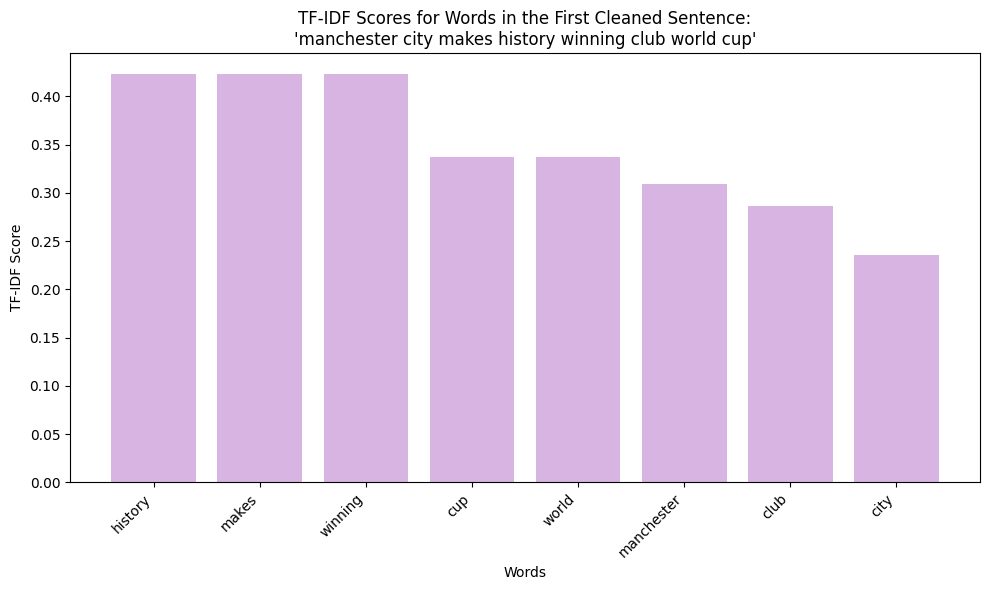

In [9]:
# Get TF-IDF scores for the first cleaned sentence
if cleaned_sentences:
    first_cleaned_sentence = cleaned_sentences[0]
    first_sentence_tfidf_df = get_tfidf_for_sentence(features, 0, feature_names)

    # Visualize the TF-IDF scores as a histogram
    plt.figure(figsize=(10, 6))
    plt.bar(first_sentence_tfidf_df['Feature'], first_sentence_tfidf_df['TF-IDF'], color='#D8B4E2')
    plt.xlabel("Words")
    plt.ylabel("TF-IDF Score")
    plt.title(f"TF-IDF Scores for Words in the First Cleaned Sentence:\n'{first_cleaned_sentence}'")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No cleaned sentences to visualize.")

## Calculate Sentence Score

**List of Sentences:**
1. Manchester City makes history by winning Club World Cup.
2. Manchester City capped off its incredible year with yet another trophy, dismantling Fluminense 4-0 to win the Club World Cup on Friday.
3. Having already won the Premier League, Champions League, FA Cup and Super Cup, Pep Guardiola’s side now boasts five trophies this calendar year, becoming the first English club to ever hold all those titles simultaneously.
4. The final piece of the jigsaw came on a highly charged night in Saudi Arabia as Manchester City outclassed its Brazilian opponents.
5. “We’ve shown over the past 12 months we are the best team in the world.
6. Our results prove that and the consistency we have managed has been amazing,” club captain Kyle Walker said after the game, per Sky Sports.
7. “To win these five trophies – for me, the five biggest prizes available to us – is incredible.
8. I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside 

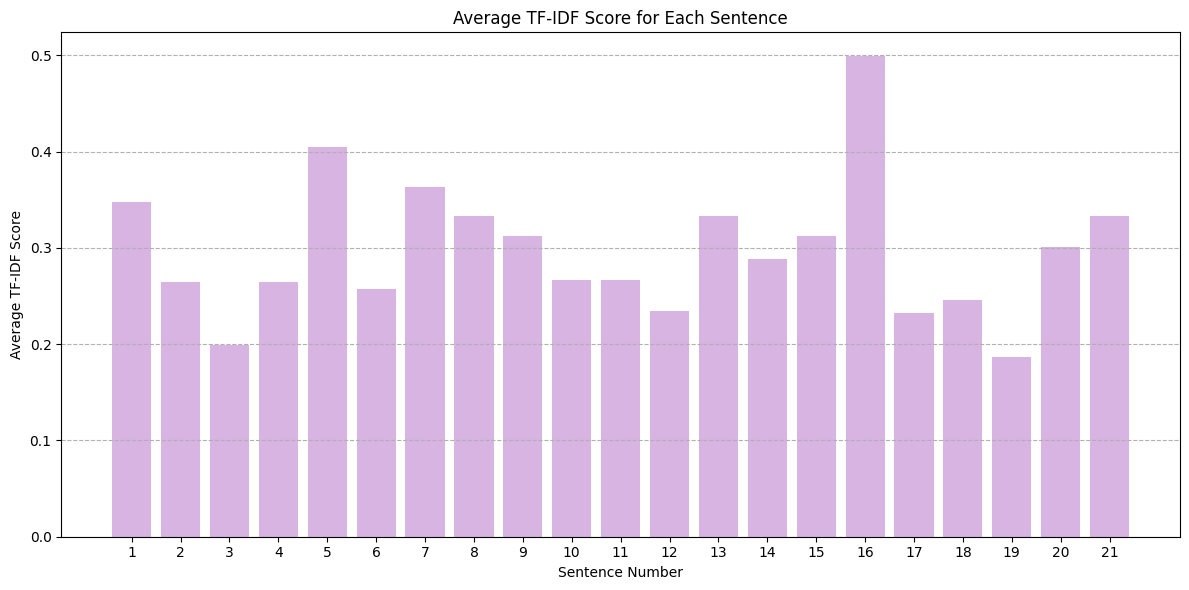


**Explanation of the Histogram :**
Imagine we've given each sentence in the news article a score based on the importance of the words it contains. This score is called the 'Average TF-IDF Score'.

The histogram above is like a bar chart that shows this score for each sentence:
- **The horizontal line (Sentence Number):** Each number on this line represents a different sentence in the article, starting from the first sentence (1) to the last.
- **The vertical bar for each sentence:** The height of each bar shows the 'Average TF-IDF Score' for that particular sentence.

**What does the height of the bar tell us?**
- **Taller bar:** A taller bar means the sentence contains words that are considered more important and unique within the entire article. These sentences likely carry more key information.
- **Shorter bar:** A shorter bar means the sentence contains words that are either less important or more common throughout the article. These sentences might be supporting details or less c

In [10]:
# Variable initialization
sent_index = 0
sent_scores = []

# Calculate sentence TF-IDF score and list sentences
print("**List of Sentences:**")
for i, sent in enumerate(sent_token):
    print(f"{i + 1}. {sent}")
print("\n-------------------------")

# Calculate average TF-IDF score for each sentence
print("\n**Average TF-IDF Score for Each Sentence:**")
for i in features:
    print(f"- Sentence {sent_index + 1}")
    sent_score = i.sum()
    sent_length = len(i.data)
    print("  Sum of TF-IDF scores:", sent_score)
    print("  Number of words:", sent_length)
    avg_score = sent_score / sent_length if sent_length > 0 else 0
    print("  Average TF-IDF score:", avg_score)
    sent_scores.append(avg_score)
    sent_index += 1
print("\n-------------------------")

print("\nList of average TF-IDF scores for each sentence:")
print(sent_scores)

# Visualize the average TF-IDF scores as a histogram
plt.figure(figsize=(12, 6))
plt.bar(range(1, len(sent_scores) + 1), sent_scores, color='#D8B4E2')
plt.xlabel("Sentence Number")
plt.ylabel("Average TF-IDF Score")
plt.title("Average TF-IDF Score for Each Sentence")
plt.xticks(range(1, len(sent_scores) + 1))
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

# Explanation:
print("\n**Explanation of the Histogram :**")
print("Imagine we've given each sentence in the news article a score based on the importance of the words it contains. This score is called the 'Average TF-IDF Score'.")
print("\nThe histogram above is like a bar chart that shows this score for each sentence:")
print("- **The horizontal line (Sentence Number):** Each number on this line represents a different sentence in the article, starting from the first sentence (1) to the last.")
print("- **The vertical bar for each sentence:** The height of each bar shows the 'Average TF-IDF Score' for that particular sentence.")
print("\n**What does the height of the bar tell us?**")
print("- **Taller bar:** A taller bar means the sentence contains words that are considered more important and unique within the entire article. These sentences likely carry more key information.")
print("- **Shorter bar:** A shorter bar means the sentence contains words that are either less important or more common throughout the article. These sentences might be supporting details or less central to the main topic.")
print("\nSo, by looking at this chart, you can quickly get a sense of which sentences in the article are likely to be the most informative based on the words they use.")

## Define Threshold

In [11]:
# Calculate the average of all sentence scores (threshold)
threshold = sum(sent_scores) / len(sent_scores) if sent_scores else 0

print("Threshold (Average of Sentence Scores):", threshold)

Threshold (Average of Sentence Scores): 0.2973415551623522


## Sentences list for manual TF-IDF checking

In [13]:
sentences = [
    "Manchester City makes history by winning Club World Cup.",
    "Manchester City capped off its incredible year with yet another trophy, dismantling Fluminense 4-0 to win the Club World Cup on Friday.",
    "Having already won the Premier League, Champions League, FA Cup and Super Cup, Pep Guardiola’s side now boasts five trophies this calendar year, becoming the first English club to ever hold all those titles simultaneously.",
    "The final piece of the jigsaw came on a highly charged night in Saudi Arabia as Manchester City outclassed its Brazilian opponents.",
    '“We’ve shown over the past 12 months we are the best team in the world."',
    '"Our results prove that and the consistency we have managed has been amazing,” club captain Kyle Walker said after the game, per Sky Sports.',
    '“To win these five trophies – for me, the five biggest prizes available to us – is incredible."',
    '"I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players. I couldn’t ask for better teammates.”',
    "It took just 40 seconds for Manchester City to take the lead.",
    "Brazilian left-back Marcelo miscued a pass in the opening exchanges which let Nathan Aké free to shoot from distance.",
    "The defender’s effort cannoned back off the post but forward Julián Álvarez was in the right place to turn the rebound into the net with his chest.",
    "City continued to look dangerous and doubled its lead before the break after Phil Foden’s attempted cross was deflected into his own net by Fluminense defender Nino.",
    "Foden then got on the scoresheet himself in the 72nd minute after a prodding home from close range.",
    "The rout was completed in the 88th minute when Álvarez capped off a brilliant performance with a clinical finish into the far corner.",
    "City’s defence was largely untested for during the game, underlining the team’s dominance during this unforgettable year.",
    '“As a manager it is what I am most proud of; that we are always there."',
    '"No matter how much we win, no matter what trophies we lift, we are there again to fight for the next one,” City boss Guardiola said after the match, according to Sky Sports.',
    '“To win the Treble was truly special, but to win two more trophies and now hold these five major titles shows the unique mentality of this team, of the Club and its fans.',
    '“It is something no other English team has ever achieved, and we will always remember this incredible time we spent together.”',
    "The game ended in some unsavoury scenes as a scuffle broke out between players on the pitch after the final whistle, but the game will be remembered as yet another successful night for City.",
    "The champion heads back to England where it faces a tough title defence in the Premier League.",
    "It currently sits fourth in the table and will face Everton in its next fixture on Wednesday."
]

# Initialize a list to store cleaned sentences
all_cleaned_sentences = []
for sentence_item in sentences:
    cleaned_sentence = clean_text(sentence_item)
    all_cleaned_sentences.append(cleaned_sentence)

# Function to calculate TF for a term in a document
def calculate_tf(term, document):
    words = word_tokenize(document.lower())
    return words.count(term) / len(words) if len(words) > 0 else 0

# Function to calculate IDF for a term across all documents
def calculate_idf(term, all_documents):
    num_documents_with_term = sum(1 for doc in all_documents if term.lower() in word_tokenize(doc.lower()))
    if num_documents_with_term > 0:
        return math.log(len(all_documents) / num_documents_with_term)
    else:
        return 0

# Calculate TF-IDF for "city" in each sentence
tfidf_scores = {}
for i, sentence_item in enumerate(sentences):
    cleaned_sentence = clean_text(sentence_item)
    tf = calculate_tf("city", cleaned_sentence)
    idf = calculate_idf("city", all_cleaned_sentences)
    tfidf = tf * idf
    tfidf_scores[f"Sentence {i+1}"] = tfidf

# Print the TF-IDF scores for "investasi" in each sentence
print("TF-IDF Score for 'city' in each cleaned sentence:")
for sentence_num, score in tfidf_scores.items():
    print(f"{sentence_num}: {score:.4f}")

# Calculate the overall IDF for "investasi" across all cleaned sentences
overall_idf_city = calculate_idf("city", all_cleaned_sentences)
print(f"\nOverall IDF for 'city': {overall_idf_city:.4f}")

TF-IDF Score for 'city' in each cleaned sentence:
Sentence 1: 0.1265
Sentence 2: 0.0723
Sentence 3: 0.0000
Sentence 4: 0.0723
Sentence 5: 0.0000
Sentence 6: 0.0000
Sentence 7: 0.0000
Sentence 8: 0.0000
Sentence 9: 0.1686
Sentence 10: 0.0000
Sentence 11: 0.0000
Sentence 12: 0.0562
Sentence 13: 0.0000
Sentence 14: 0.0000
Sentence 15: 0.1012
Sentence 16: 0.0000
Sentence 17: 0.0562
Sentence 18: 0.0000
Sentence 19: 0.0000
Sentence 20: 0.0562
Sentence 21: 0.0000
Sentence 22: 0.0000

Overall IDF for 'city': 1.0116


## Get Sentences

In [14]:
print("Threshold (Average of Sentence Scores):", threshold)

# Final summary initialization
final_summ = ""

if len(sent_scores) > len(sent_token):
    sent_scores = sent_scores[:len(sent_token)]

# Get summary sentences
print("\n**Summary Sentences (above or equal to the threshold):**")
for index, data in enumerate(sent_scores):
    if data >= threshold:
        final_summ = final_summ + " " + sent_token[index]
        print(f"- {sent_token[index]}")

print("\n**Final Summary:**")
print(final_summ.strip())

Threshold (Average of Sentence Scores): 0.2973415551623522

**Summary Sentences (above or equal to the threshold):**
- Manchester City makes history by winning Club World Cup.
- “We’ve shown over the past 12 months we are the best team in the world.
- “To win these five trophies – for me, the five biggest prizes available to us – is incredible.
- I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players.
- I couldn’t ask for better teammates.”
It took just 40 seconds for Manchester City to take the lead.
- Foden then got on the scoresheet himself in the 72nd minute after a prodding home from close range.
- City’s defence was largely untested for during the game, underlining the team’s dominance during this unforgettable year.
- “As a manager it is what I am most proud of; that we are always there.
- The champion heads back to England where it faces a tough title defence in the Premier League.
- It currently sits fourth in the table 

## TF-IDF "investasi" using TfidfVectorizer

In [17]:
sentences = [
    "Manchester City makes history by winning Club World Cup.",
    "Manchester City capped off its incredible year with yet another trophy, dismantling Fluminense 4-0 to win the Club World Cup on Friday.",
    "Having already won the Premier League, Champions League, FA Cup and Super Cup, Pep Guardiola’s side now boasts five trophies this calendar year, becoming the first English club to ever hold all those titles simultaneously.",
    "The final piece of the jigsaw came on a highly charged night in Saudi Arabia as Manchester City outclassed its Brazilian opponents.",
    '“We’ve shown over the past 12 months we are the best team in the world."',
    '"Our results prove that and the consistency we have managed has been amazing,” club captain Kyle Walker said after the game, per Sky Sports.',
    '“To win these five trophies – for me, the five biggest prizes available to us – is incredible."',
    '"I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players. I couldn’t ask for better teammates.”',
    "It took just 40 seconds for Manchester City to take the lead.",
    "Brazilian left-back Marcelo miscued a pass in the opening exchanges which let Nathan Aké free to shoot from distance.",
    "The defender’s effort cannoned back off the post but forward Julián Álvarez was in the right place to turn the rebound into the net with his chest.",
    "City continued to look dangerous and doubled its lead before the break after Phil Foden’s attempted cross was deflected into his own net by Fluminense defender Nino.",
    "Foden then got on the scoresheet himself in the 72nd minute after a prodding home from close range.",
    "The rout was completed in the 88th minute when Álvarez capped off a brilliant performance with a clinical finish into the far corner.",
    "City’s defence was largely untested for during the game, underlining the team’s dominance during this unforgettable year.",
    '“As a manager it is what I am most proud of; that we are always there."',
    '"No matter how much we win, no matter what trophies we lift, we are there again to fight for the next one,” City boss Guardiola said after the match, according to Sky Sports.',
    '“To win the Treble was truly special, but to win two more trophies and now hold these five major titles shows the unique mentality of this team, of the Club and its fans.',
    '“It is something no other English team has ever achieved, and we will always remember this incredible time we spent together.”',
    "The game ended in some unsavoury scenes as a scuffle broke out between players on the pitch after the final whistle, but the game will be remembered as yet another successful night for City.",
    "The champion heads back to England where it faces a tough title defence in the Premier League.",
    "It currently sits fourth in the table and will face Everton in its next fixture on Wednesday."
]

# Function to calculate TF for a term in a document
def calculate_tf(term, document):
    words = word_tokenize(document.lower())
    return words.count(term) / len(words) if len(words) > 0 else 0

# Function to calculate IDF for a term across all documents
def calculate_idf(term, all_documents):
    num_documents_with_term = sum(1 for doc in all_documents if term.lower() in word_tokenize(doc.lower()))
    if num_documents_with_term > 0:
        return math.log(len(all_documents) / num_documents_with_term)
    else:
        return 0

# Calculate TF-IDF for "investasi" in each sentence
tfidf_scores = {}
all_cleaned_sentences = []

for i, sentence_item in enumerate(sentences):
    cleaned_sentence = clean_text(sentence_item)
    all_cleaned_sentences.append(cleaned_sentence)
    tf = calculate_tf("investasi", cleaned_sentence)
    idf = calculate_idf("investasi", all_cleaned_sentences)
    tfidf = tf * idf
    tfidf_scores[f"Sentence {i+1}"] = tfidf

# Print the TF-IDF scores for "investasi" in each sentence
print("TF-IDF Score for 'city' in each sentence:")
for sentence_num, score in tfidf_scores.items():
    print(f"{sentence_num}: {score:.4f}")

# Calculate the overall IDF for "investasi" across all cleaned sentences
overall_idf_city = calculate_idf("city", all_cleaned_sentences)
print(f"\nOverall IDF for 'city': {overall_idf_city:.4f}")

# Use scikit-learn's TfidfVectorizer
vectorizer_check = TfidfVectorizer(stop_words=list(stopword_en))
tfidf_matrix = vectorizer_check.fit_transform(sentences)
feature_names = vectorizer_check.get_feature_names_out()

try:
    city_index = list(feature_names).index("city")
    print("\nTF-IDF Score for 'city' using TfidfVectorizer:")
    for i, sentence_item in enumerate(sentences):
        tfidf = tfidf_matrix[i, city_index]
        print(f"Sentence {i+1}: {tfidf:.4f}")
except ValueError:
    print("\n'city' not found in the vocabulary after stop word removal by TfidfVectorizer.")

TF-IDF Score for 'city' in each sentence:
Sentence 1: 0.0000
Sentence 2: 0.0000
Sentence 3: 0.0000
Sentence 4: 0.0000
Sentence 5: 0.0000
Sentence 6: 0.0000
Sentence 7: 0.0000
Sentence 8: 0.0000
Sentence 9: 0.0000
Sentence 10: 0.0000
Sentence 11: 0.0000
Sentence 12: 0.0000
Sentence 13: 0.0000
Sentence 14: 0.0000
Sentence 15: 0.0000
Sentence 16: 0.0000
Sentence 17: 0.0000
Sentence 18: 0.0000
Sentence 19: 0.0000
Sentence 20: 0.0000
Sentence 21: 0.0000
Sentence 22: 0.0000

Overall IDF for 'city': 1.0116

TF-IDF Score for 'city' using TfidfVectorizer:
Sentence 1: 0.2381
Sentence 2: 0.1804
Sentence 3: 0.0000
Sentence 4: 0.1613
Sentence 5: 0.0000
Sentence 6: 0.0000
Sentence 7: 0.0000
Sentence 8: 0.0000
Sentence 9: 0.2372
Sentence 10: 0.0000
Sentence 11: 0.0000
Sentence 12: 0.1399
Sentence 13: 0.0000
Sentence 14: 0.0000
Sentence 15: 0.2002
Sentence 16: 0.0000
Sentence 17: 0.1354
Sentence 18: 0.0000
Sentence 19: 0.0000
Sentence 20: 0.1366
Sentence 21: 0.0000
Sentence 22: 0.0000


In [18]:
final_summ

' Manchester City makes history by winning Club World Cup. “We’ve shown over the past 12 months we are the best team in the world. “To win these five trophies – for me, the five biggest prizes available to us – is incredible. I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players. I couldn’t ask for better teammates.”\nIt took just 40 seconds for Manchester City to take the lead. Foden then got on the scoresheet himself in the 72nd minute after a prodding home from close range. City’s defence was largely untested for during the game, underlining the team’s dominance during this unforgettable year. “As a manager it is what I am most proud of; that we are always there. The champion heads back to England where it faces a tough title defence in the Premier League. It currently sits fourth in the table and will face Everton in its next fixture on Wednesday.'

## Summarization Result

In [19]:
# Final summary initialization
final_summ = ""

# Get summary sentences
for index, data in enumerate(sent_scores):
    if data >= threshold:
        final_summ = final_summ + " " + sent_token[index]
        print("- ", sent_token[index])

-  Manchester City makes history by winning Club World Cup.
-  “We’ve shown over the past 12 months we are the best team in the world.
-  “To win these five trophies – for me, the five biggest prizes available to us – is incredible.
-  I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players.
-  I couldn’t ask for better teammates.”
It took just 40 seconds for Manchester City to take the lead.
-  Foden then got on the scoresheet himself in the 72nd minute after a prodding home from close range.
-  City’s defence was largely untested for during the game, underlining the team’s dominance during this unforgettable year.
-  “As a manager it is what I am most proud of; that we are always there.
-  The champion heads back to England where it faces a tough title defence in the Premier League.
-  It currently sits fourth in the table and will face Everton in its next fixture on Wednesday.


In [20]:
final_summ

' Manchester City makes history by winning Club World Cup. “We’ve shown over the past 12 months we are the best team in the world. “To win these five trophies – for me, the five biggest prizes available to us – is incredible. I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players. I couldn’t ask for better teammates.”\nIt took just 40 seconds for Manchester City to take the lead. Foden then got on the scoresheet himself in the 72nd minute after a prodding home from close range. City’s defence was largely untested for during the game, underlining the team’s dominance during this unforgettable year. “As a manager it is what I am most proud of; that we are always there. The champion heads back to England where it faces a tough title defence in the Premier League. It currently sits fourth in the table and will face Everton in its next fixture on Wednesday.'